<a href="https://colab.research.google.com/github/MankotiaGit/Statistical-Foundation-of-Data-Sciences-/blob/main/SFDS_PRACTICAL_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: import the libraries

Step 2: load the dataset

Step 3: display the dataset information

Step 4: find duplicate professors

Step 5: find total number of observations

Step 6: find number of unique instructors

Step 7: calculate average age

Step 8: calculate standard deviation of age

Step 9: keep one observation for each instructor

Step 10: check the number of observations after filtering

Step 11: calculate average age after filtering

Step 12: calculate standard deviation after filtering

Step 13: calculate average evaluation by division

Step 14: create bar chart

Step 15: calculate correlation

Step 16: create scatterplot

Step 17: create a figure for two plots

Step 18: filter female instructors

Step 19: create male scatterplot

Step 20: adjust and display the plots

Step 21: create figure

Step 22: loop through gender

Step 23: loop through tenure

Step 24: filter data using gender and tenure

Step 25: select marker according to tenure

Step 26: create the scatterplot

Step 27: add axis labels

Step 28: add title

Step 29: display legend

Step 30: display the graph



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
url = "https://vincentarelbundock.github.io/Rdatasets/csv/AER/TeachingRatings.csv"

In [ ]:
df = pd.read_csv(url)

In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (463, 13)


In [ ]:
print(df.head())

   rownames minority  age  gender credits    beauty  eval division native  \
0         1      yes   36  female    more  0.289916   4.3    upper    yes   
1         2       no   59    male    more -0.737732   4.5    upper    yes   
2         3       no   51    male    more -0.571984   3.7    upper    yes   
3         4       no   40  female    more -0.677963   4.3    upper    yes   
4         5       no   31  female    more  1.509794   4.4    upper    yes   

  tenure  students  allstudents  prof  
0    yes        24           43     1  
1    yes        17           20     2  
2    yes        55           55     3  
3    yes        40           46     4  
4    yes        42           48     5  


(Q1)  Duplicate cases using prof

In [ ]:
# Find duplicate cases
duplicates = df[df.duplicated(subset="prof", keep=False)]
print("\nDuplicate cases:")
print(duplicates)



Duplicate cases:
     rownames minority  age  gender credits    beauty  eval division native  \
0           1      yes   36  female    more  0.289916   4.3    upper    yes   
1           2       no   59    male    more -0.737732   4.5    upper    yes   
2           3       no   51    male    more -0.571984   3.7    upper    yes   
3           4       no   40  female    more -0.677963   4.3    upper    yes   
4           5       no   31  female    more  1.509794   4.4    upper    yes   
..        ...      ...  ...     ...     ...       ...   ...      ...    ...   
458       459       no   32    male    more  1.231394   3.2    lower    yes   
459       460       no   32    male    more  1.231394   4.3    upper    yes   
460       461      yes   42  female    more  0.420400   3.3    upper     no   
461       462      yes   42  female    more  0.420400   3.2    upper     no   
462       463      yes   42  female  single  0.420400   4.1    lower     no   

    tenure  students  allstudents

In [ ]:

print("\nTotal observations:", len(df))


Total observations: 463


In [ ]:

print("Unique instructors:", df["prof"].nunique())


Unique instructors: 94


In [ ]:

mean_age = df["age"].mean()

In [ ]:

std_age = df["age"].std()

print("\nUsing all observations:")
print("Average age =", mean_age)
print("Standard deviation =", std_age)


Using all observations:
Average age = 48.365010799136066
Standard deviation = 9.802742037864817


In [ ]:

df_unique = df.drop_duplicates(subset="prof", keep="first")

print("\nAfter removing duplicate instructors:")
print("Number of observations:", len(df_unique))

mean_age_unique = df_unique["age"].mean()
std_age_unique = df_unique["age"].std()

print("Average age =", mean_age_unique)
print("Standard deviation =", std_age_unique)


After removing duplicate instructors:
Number of observations: 94
Average age = 47.5531914893617
Standard deviation = 10.256513295154951


(Q2) Bar chart for division and evaluation


Average evaluation by division:
division
lower    4.087261
upper    3.952614
Name: eval, dtype: float64


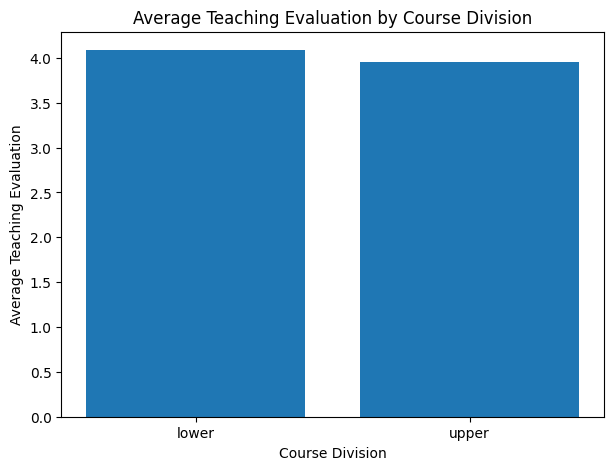

In [ ]:

avg_eval_division = df.groupby("division")["eval"].mean()

print("\nAverage evaluation by division:")
print(avg_eval_division)

plt.figure(figsize=(7,5))

plt.bar(
    avg_eval_division.index,
    avg_eval_division.values
)

plt.xlabel("Course Division")
plt.ylabel("Average Teaching Evaluation")
plt.title("Average Teaching Evaluation by Course Division")

plt.show()


(Q3) Age vs Evaluation

Correlation between age and evaluation = -0.051696190877182864


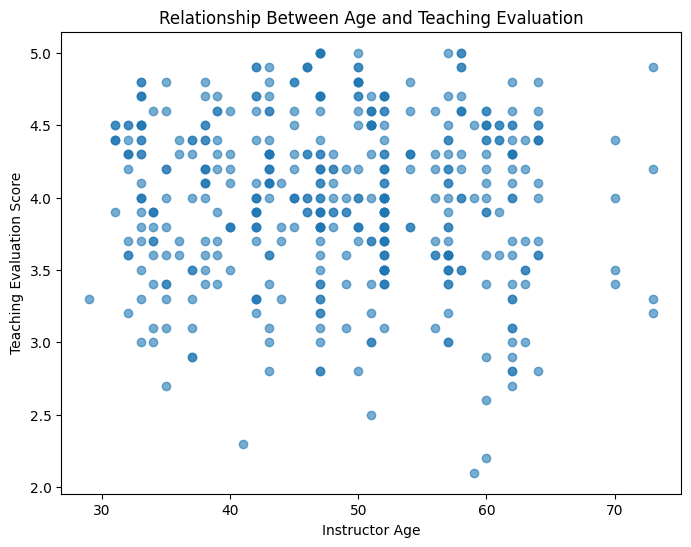

In [ ]:
correlation = df["age"].corr(df["eval"])

print("Correlation between age and evaluation =", correlation)

plt.figure(figsize=(8,6))

plt.scatter(
    df["age"],
    df["eval"],
    alpha=0.6
)

plt.xlabel("Instructor Age")
plt.ylabel("Teaching Evaluation Score")
plt.title("Relationship Between Age and Teaching Evaluation")

plt.show()

(Q4) Gender differentiated scatterplots

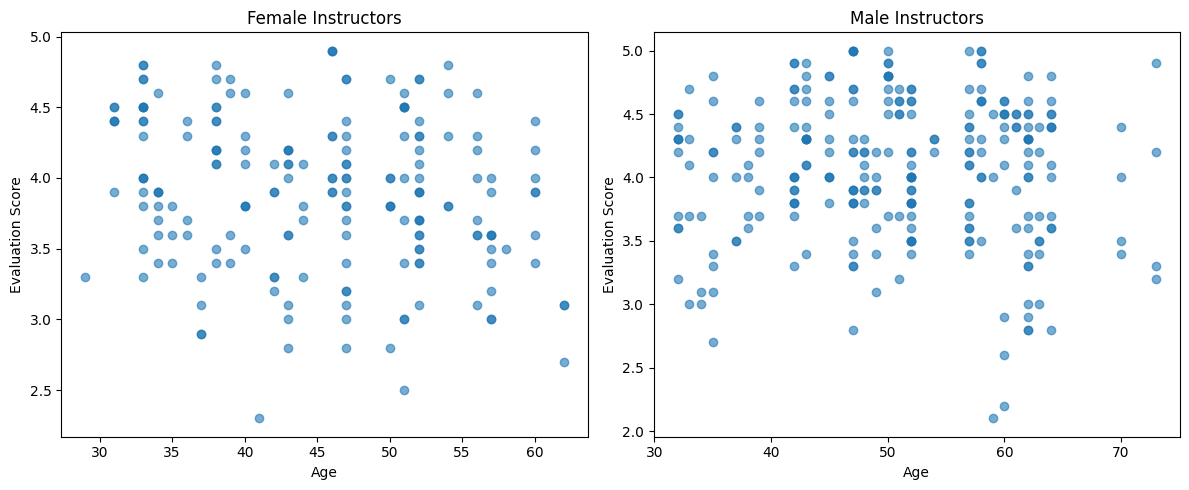

In [ ]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

female = df[df["gender"] == "female"]

plt.scatter(
    female["age"],
    female["eval"],
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Evaluation Score")
plt.title("Female Instructors")


plt.subplot(1,2,2)

male = df[df["gender"] == "male"]

plt.scatter(
    male["age"],
    male["eval"],
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Evaluation Score")
plt.title("Male Instructors")

plt.tight_layout()
plt.show()



(Q5) Gender + Tenure differentiated scatterplot

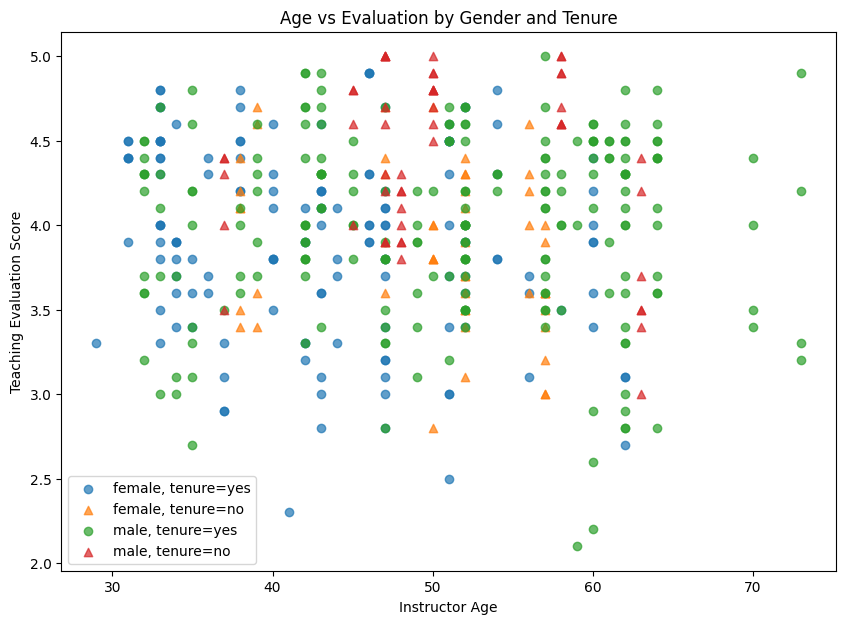

In [ ]:
plt.figure(figsize=(10,7))

for gender in df["gender"].unique():

    for tenure in df["tenure"].unique():

        subset = df[
            (df["gender"] == gender) &
            (df["tenure"] == tenure)
        ]

        marker = "o" if tenure == "yes" else "^"

        plt.scatter(
            subset["age"],
            subset["eval"],
            label=f"{gender}, tenure={tenure}",
            marker=marker,
            alpha=0.7
        )

plt.xlabel("Instructor Age")
plt.ylabel("Teaching Evaluation Score")
plt.title("Age vs Evaluation by Gender and Tenure")

plt.legend()
plt.show()